In [2]:
# PRUEBA DE INSTALACION DE DEVSIM

##### IMPORTAR LIBRERIAS
## Manejo de archivos
import os
## Devsim standard
from devsim import *
from matplotlib.pyplot import semilogy

## Devsim custom
import src.diode_common as diode_common
from src.new_physics import *
from src.plot import *
## Graficos
import matplotlib.pyplot as plt
import matplotlib.tri as tri
import matplotlib.cm as cm
## Numerico
import numpy as np

# CODIGO DE PRUEBA

Hecho por los profes

In [3]:

##### PARAMETROS GLOBALES FIJOS
device = "Diodo"
region = "AreaDiodo"

In [4]:
##### DECLARACION DE VARIABLES
totalCurrent = []
appliedVoltage = []
electronCurrent = []
holeCurrent = []

#### Parámetros globales modificables

![image.png](res/img_1.png)


![image.png](res/img.png)

In [5]:
## Tension aplicada
Va_min = -0.3 # [V] Minima tension en reversa
Va_max = 0.4 # [V] Maxima tension en directa
paso = 0.005 # [V] Pasos de tension en el barrido#####################################################################
##### PARAMETROS GLOBALES MODIFICABLES

##### Dimensiones, dopajes y tiempos de vida
Na = 6e15 # [cm-3] Dopaje aceptor lado P
Nd = 3e15 # [cm-3] Dopaje donor lado N
Wp = 9e-4 # [cm] Extension lado P (incluyendo QNR-P y zona de vaciamiento P)
Wn = 7e-4 # [cm] Extension lado N (incluyendo QNR-N y zona de vaciamiento N)
taup = 37e-6 # Tiempo de vida de los minoritarios
taun = 37e-6 # Tiempo de vida de los minoritarios

##### Habilitador del modelo Shockley-Reed-Hall
enable_SRH = False

##### Mostrar graficos
show_plots = True

#####################################################################

#### Parámetros globales fijos

Creating Region air3
Creating Region air4
Creating Region AreaDiodo
Creating Region air2
Contact: Anodo region AreaDiodo ni: 1 ci: 24 (0, 0, 0)
Contact: Anodo region AreaDiodo ni: 4 ci: 25 (0, 5e-05, 0)
Contact: Anodo region AreaDiodo ni: 6 ci: 26 (0, 0.0001, 0)
Contact: Anodo region AreaDiodo ni: 8 ci: 27 (0, 0.00015, 0)
Contact: Anodo region AreaDiodo ni: 10 ci: 28 (0, 0.0002, 0)
Contact: Anodo region AreaDiodo ni: 12 ci: 29 (0, 0.00025, 0)
Contact: Anodo region AreaDiodo ni: 14 ci: 30 (0, 0.0003, 0)
Contact: Anodo region AreaDiodo ni: 16 ci: 31 (0, 0.00035, 0)
Contact: Anodo region AreaDiodo ni: 18 ci: 32 (0, 0.0004, 0)
Contact: Anodo region AreaDiodo ni: 20 ci: 33 (0, 0.00045, 0)
Contact: Anodo region AreaDiodo ni: 22 ci: 34 (0, 0.0005, 0)
Contact: Anodo region AreaDiodo ni: 24 ci: 35 (0, 0.00055, 0)
Contact: Anodo region AreaDiodo ni: 26 ci: 36 (0, 0.0006, 0)
Contact: Anodo region AreaDiodo ni: 28 ci: 37 (0, 0.00065, 0)
Contact: Anodo region AreaDiodo ni: 30 ci: 38 (0, 0.0007, 0)


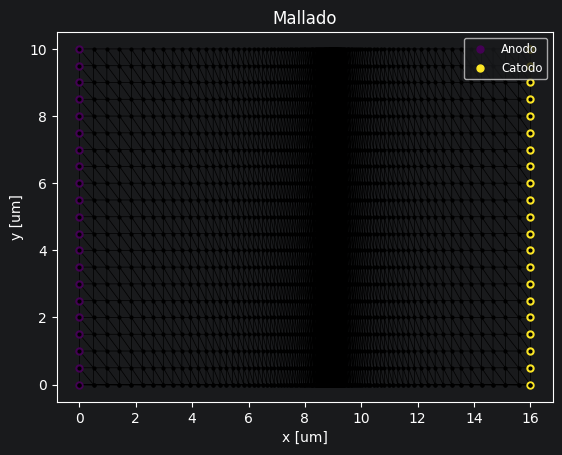

In [6]:
altura = 10e-4 # [cm] Altura del diodo. A mayor altura, mayor corriente
Wtotal = Wp + Wn # [cm] Extension total del diodo
interfaz = Wp

##### CREAR MALLADO Y MOSTRARLO
low_res = 0.5e-4
high_res = low_res/50
diode_common.Create2DMesh(device, region, interface=interfaz, height=altura, total_width=Wtotal, low_res=low_res, high_res=high_res)

contactos = ["Anodo", "Catodo"]

if show_plots:
    plot_mesh_with_contacts(contactos=contactos, device=device, region=region)

#### Asociar parámetros del silicio

/home/fadelrio/Ingenieria/Dispositivos Semiconductores Nueva/TP3/app_rara/.venv/lib/python3.13/site-packages/matplotlib/tri/_triangulation.py:181: RuntimeWarning: invalid value encountered in cast
  triangles = np.asarray(triangles, dtype=np.int32)


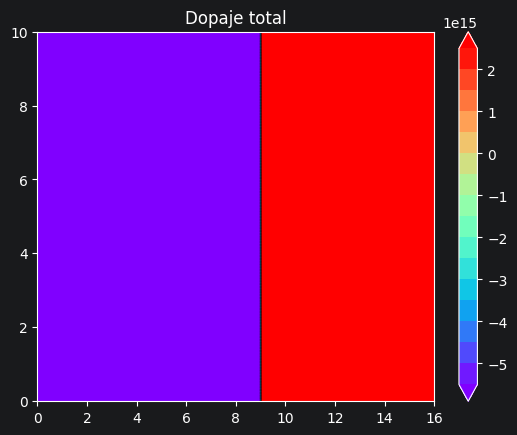

In [7]:
diode_common.SetParameters(device=device, region=region)
set_parameter(device=device, region=region, name="taun", value=taun)
set_parameter(device=device, region=region, name="taup", value=taup)

##### ASOCIAR DOPAJES
diode_common.SetNetDoping(device=device, region=region, Na=Na, Nd=Nd, interface=interfaz)

##### GRAFICAR DOPAJES
if show_plots:
    plot_doping(device,region)

###################################################################
########### VD = 0V / ETD #########################################
###################################################################

#### $V_d = 0V$

Replacing Edge Model EField in region AreaDiodo of material Si
Replacing Edge Model EField:Potential@n0 in region AreaDiodo of material Si
Replacing Edge Model EField:Potential@n1 in region AreaDiodo of material Si
number of equations 2794
Iteration: 0
  Device: "Diodo"	RelError: 1.00000e+00	AbsError: 2.25149e-01
    Region: "AreaDiodo"	RelError: 1.00000e+00	AbsError: 2.25149e-01
      Equation: "PotentialEquation"	RelError: 1.00000e+00	AbsError: 2.25149e-01
Iteration: 1
  Device: "Diodo"	RelError: 3.00905e+01	AbsError: 1.54408e-01
    Region: "AreaDiodo"	RelError: 3.00905e+01	AbsError: 1.54408e-01
      Equation: "PotentialEquation"	RelError: 3.00905e+01	AbsError: 1.54408e-01
Iteration: 2
  Device: "Diodo"	RelError: 7.52202e+01	AbsError: 1.77641e-01
    Region: "AreaDiodo"	RelError: 7.52202e+01	AbsError: 1.77641e-01
      Equation: "PotentialEquation"	RelError: 7.52202e+01	AbsError: 1.77641e-01
Iteration: 3
  Device: "Diodo"	RelError: 8.48578e+01	AbsError: 1.62252e-01
    Region: "Are

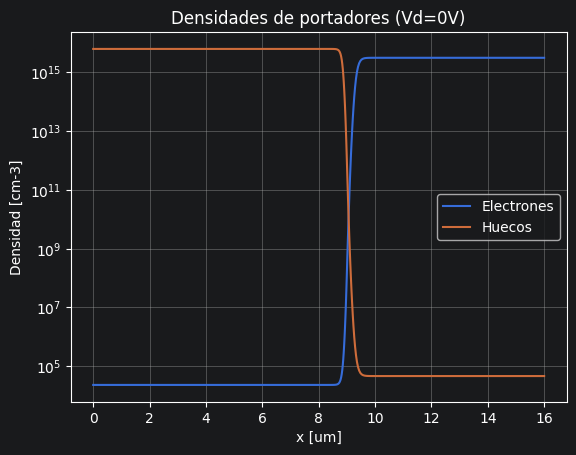

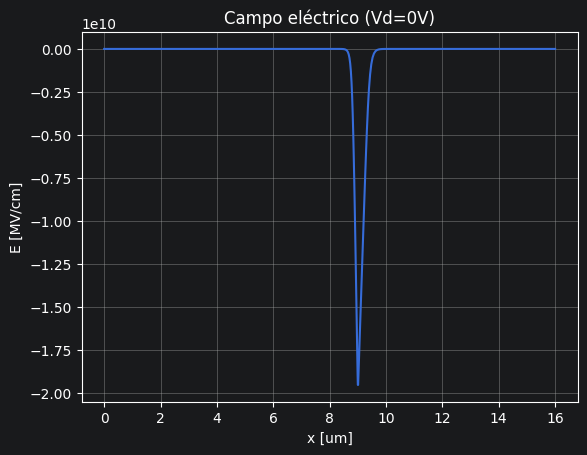

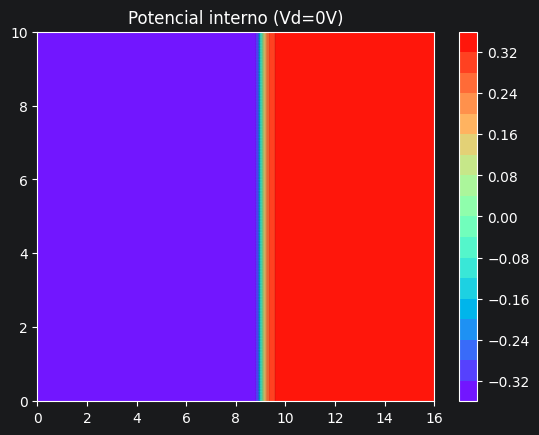

In [8]:
###### RESOLVER EL DIODO CUANDO Vd = 0V
## Para hallar una semilla sobre la cual generar el barrido posterior
# Primera solucion considerando solamente la ecuación de Poisson
diode_common.InitialSolution(device, region)
CreateEField(device, region)

solve(type="dc", absolute_error=1.0, relative_error=1e-12, maximum_iterations=30)
# Mejorar solucion incorporando las ecuaciones de arrastre y difusion J = Jarr + Jdif
diode_common.DriftDiffusionInitialSolution(device, region, enable_SRH)
solve(type="dc", absolute_error=1e10, relative_error=1e-10, maximum_iterations=30)

edge_from_node_model(device=device, region=region, node_model="x")
edge_from_node_model(device=device, region=region, node_model="y")
edge_model(device=device, region=region, name="x_edge", equation="0.5*(x@n0 + x@n1)")
edge_model(device=device, region=region, name="y_edge", equation="0.5*(y@n0 + y@n1)")

###### GRAFICAR LA DENSIDAD DE PORTADORES CUANDO Vd = 0V
n_etd, p_etd = get_carriers(device, region, 0, show_plots)
###### GRAFICAR EL CAMPO ELECTRICO INTERNO CUANDO Vd = 0V
x_Efield, E_etd = get_Efield(device, region, 0, show_plots)
###### GRAFICAR EL POTENCIAL INTERNO CUANDO Vd = 0V
phi_etd = get_potential(device, region, 0, show_plots)
###### GRAFICAR LAS CORRIENTES INTERNAS CUANDO Vd = 0V
Jn_etd, Jp_etd = get_currents(device, region, 0, False)

#### $V_D = V_a_{min}$
#### Inversa

number of equations 8382
Iteration: 0
  Device: "Diodo"	RelError: 7.24115e-15	AbsError: 1.48203e+00
    Region: "AreaDiodo"	RelError: 7.24115e-15	AbsError: 1.48203e+00
      Equation: "ElectronContinuityEquation"	RelError: 2.19388e-15	AbsError: 4.51978e-01
      Equation: "HoleContinuityEquation"	RelError: 2.46814e-15	AbsError: 1.03005e+00
      Equation: "PotentialEquation"	RelError: 2.57913e-15	AbsError: 3.61514e-17
number of equations 8382
Iteration: 0
  Device: "Diodo"	RelError: 7.72428e-01	AbsError: 5.25066e+13
    Region: "AreaDiodo"	RelError: 7.72428e-01	AbsError: 5.25066e+13
      Equation: "ElectronContinuityEquation"	RelError: 2.33688e-01	AbsError: 2.15068e+13
      Equation: "HoleContinuityEquation"	RelError: 2.29508e-01	AbsError: 3.09997e+13
      Equation: "PotentialEquation"	RelError: 3.09231e-01	AbsError: 5.00000e-03
Iteration: 1
  Device: "Diodo"	RelError: 4.09469e-02	AbsError: 3.64622e+11
    Region: "AreaDiodo"	RelError: 4.09469e-02	AbsError: 3.64622e+11
      Equatio

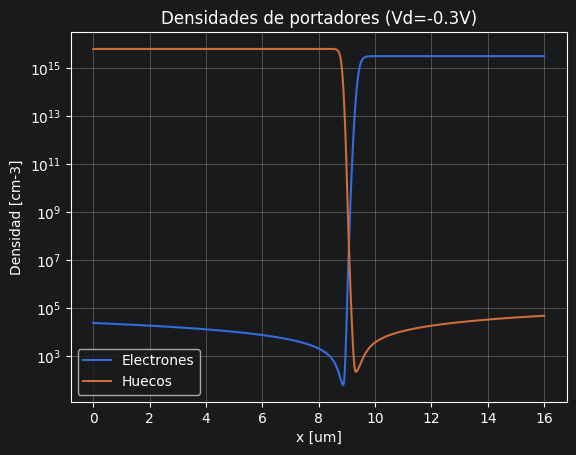

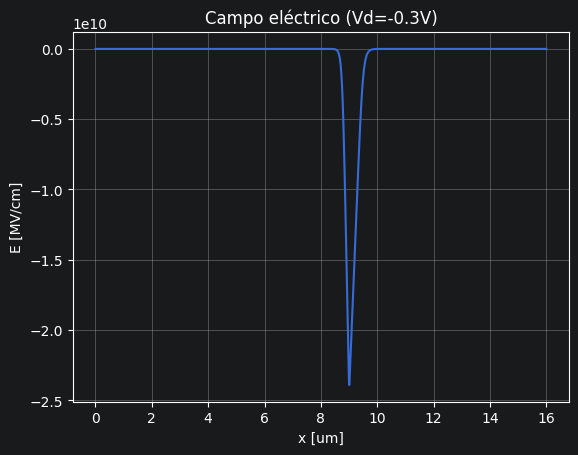

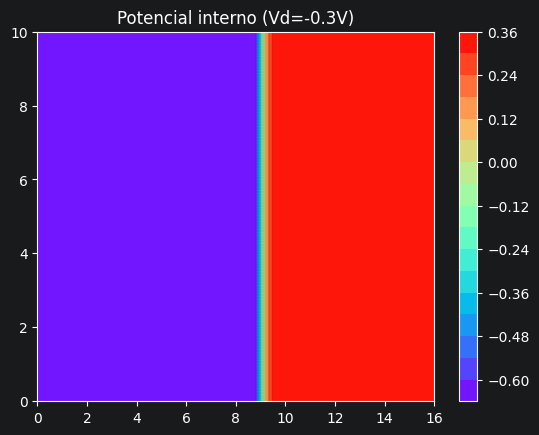

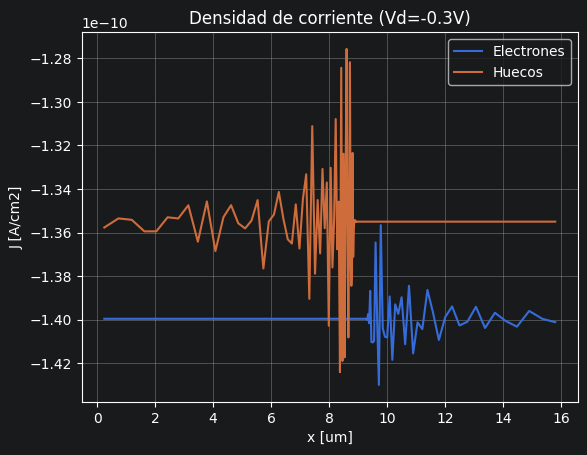

In [9]:
###### LLEVAR EL DIODO A REVERSA
v = 0.0
while v > Va_min:
    set_parameter(device=device, name=GetContactBiasName("Anodo"), value=v)
    solve(type="dc", absolute_error=1e10, relative_error=1e-10, maximum_iterations=30)
    v -= paso

###### GRAFICAR LA DENSIDAD DE PORTADORES EN REVERSA
n_Vamin, p_Vamin = get_carriers(device, region, Va_min, show_plots)
###### GRAFICAR EL CAMPO ELECTRICO INTERNO EN REVERSA
x_Efield, E_Vamin = get_Efield(device, region, Va_min, show_plots)
###### GRAFICAR EL POTENCIAL INTERNO EN REVERSA
phi_Vamin = get_potential(device, region, Va_min, show_plots)
###### GRAFICAR LAS CORRIENTES INTERNAS EN REVERSA
Jn_Vamin, Jp_Vamin = get_currents(device, region, Va_min, show_plots)

#### $V_D = V_a_{max}$
#### Directa

number of equations 8382
Iteration: 0
  Device: "Diodo"	RelError: 4.22484e-01	AbsError: 4.33056e+13
    Region: "AreaDiodo"	RelError: 4.22484e-01	AbsError: 4.33056e+13
      Equation: "ElectronContinuityEquation"	RelError: 1.59815e-01	AbsError: 1.78443e+13
      Equation: "HoleContinuityEquation"	RelError: 1.29390e-01	AbsError: 2.54614e+13
      Equation: "PotentialEquation"	RelError: 1.33278e-01	AbsError: 5.00000e-03
Iteration: 1
  Device: "Diodo"	RelError: 1.83109e-02	AbsError: 2.37496e+11
    Region: "AreaDiodo"	RelError: 1.83109e-02	AbsError: 2.37496e+11
      Equation: "ElectronContinuityEquation"	RelError: 1.07687e-02	AbsError: 1.17273e+11
      Equation: "HoleContinuityEquation"	RelError: 7.45627e-03	AbsError: 1.20223e+11
      Equation: "PotentialEquation"	RelError: 8.59033e-05	AbsError: 3.02796e-06
Iteration: 2
  Device: "Diodo"	RelError: 1.05808e-06	AbsError: 1.46444e+06
    Region: "AreaDiodo"	RelError: 1.05808e-06	AbsError: 1.46444e+06
      Equation: "ElectronContinuityEqu

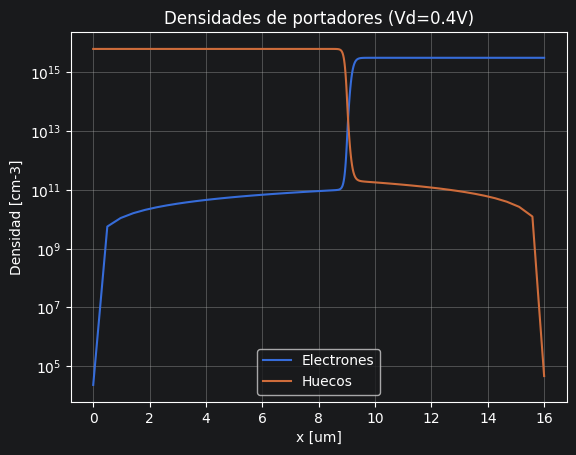

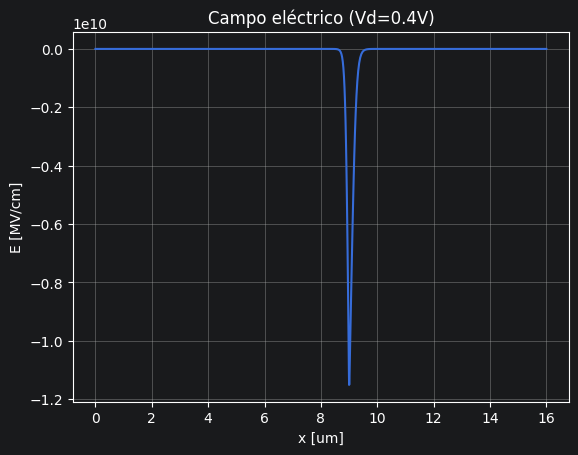

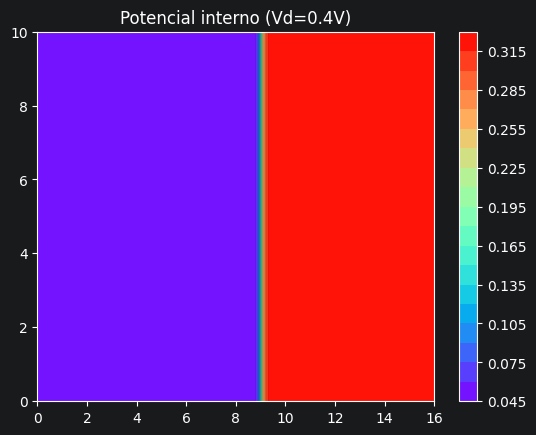

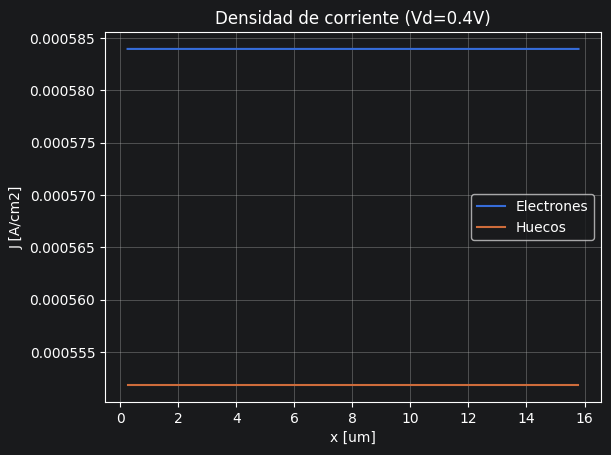

In [10]:
###### LLEVAR EL DIODO A DIRECTA Y ALMACENAR LAS CORRIENTES EN SU RECORRIDO
while v < Va_max:
    set_parameter(device=device, name=GetContactBiasName("Anodo"), value=v)
    solve(type="dc", absolute_error=1e10, relative_error=1e-10, maximum_iterations=30)

    electronCurrent_i = get_contact_current(
        device=device, contact="Anodo", equation="ElectronContinuityEquation"
    )
    holeCurrent_i = get_contact_current(
        device=device, contact="Anodo", equation="HoleContinuityEquation"
    )
    electronCurrent.append(electronCurrent_i)
    holeCurrent.append(holeCurrent_i)
    totalCurrent.append(electronCurrent_i + holeCurrent_i)
    appliedVoltage.append(v)
    v += paso

###### GRAFICAR LA DENSIDAD DE PORTADORES EN DIRECTA
n_Vamax, p_Vamax = get_carriers(device, region, Va_max, show_plots)
###### GRAFICAR EL CAMPO ELECTRICO INTERNO EN DIRECTA
x_Efield, E_Vamax = get_Efield(device, region, Va_max, show_plots)
###### GRAFICAR EL POTENCIAL INTERNO EN DIRECTA
phi_Vamax = get_potential(device, region, Va_max, show_plots)
###### GRAFICAR LAS CORRIENTES INTERNAS EN DIRECTA
Jn_Vamax, Jp_Vamax = get_currents(device, region, Va_max, show_plots)

#### PUNTO 4

Confeccionar los gr ́aficos de la densidad de carga, el campo el ́ectrico y la funci ́on
potencial el ́ectrica en funci ́on de la distancia usando DEVSIM. Cada uno debe tener tres curvas
(ETD y las dos tensiones aplicadas).

In [11]:
plt.style.use('default')

In [12]:
dE_dx_etd = np.diff(E_etd) / np.diff(x_Efield)
x_mid_etd = (x_Efield[1:] + x_Efield[:-1]) / 2

eps0 = 8.854187817e-12  # F/m
eps_si = 11.7 * eps0    # F/m

rho_etd = eps_si * dE_dx_etd * 1e-2 #-> paso a F/cm

In [13]:
dE_dx_Vamin = np.diff(E_Vamin) / np.diff(x_Efield)
x_mid_Vamin = (x_Efield[1:] + x_Efield[:-1]) / 2

eps0 = 8.854187817e-12  # F/m
eps_si = 11.7 * eps0    # F/m

rho_Vamin = eps_si * dE_dx_Vamin * 1e-2 #-> paso a F/cm

In [14]:
dE_dx_Vamax = np.diff(E_Vamax) / np.diff(x_Efield)
x_mid_Vamax = (x_Efield[1:] + x_Efield[:-1]) / 2

eps0 = 8.854187817e-12  # F/m
eps_si = 11.7 * eps0    # F/m

rho_Vamax = eps_si * dE_dx_Vamax * 1e-2 #-> paso a F/cm

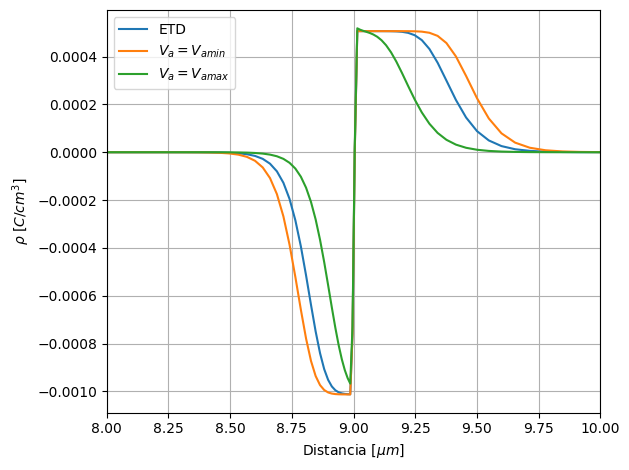

In [15]:
plt.figure()
plt.ylabel(r"$\rho$ [$C/cm^3$]")
plt.plot(1e4*x_mid_etd, rho_etd, label = "ETD")
plt.plot(1e4*x_mid_Vamin, rho_Vamin, label =r"$V_a = V_{amin}$")
plt.plot(1e4*x_mid_Vamax, rho_Vamax, label =r"$V_a = V_{amax}$")
plt.legend()
plt.grid()
plt.xlim([8,10])
plt.xlabel(r"Distancia [$\mu m$]")
plt.tight_layout()
plt.savefig("res/fig_4_densidades.pdf")
plt.show()

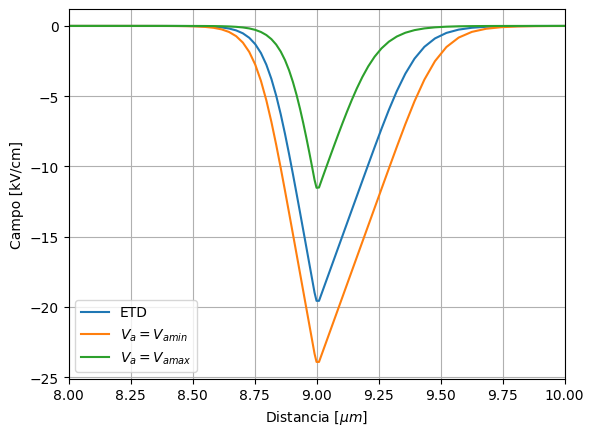

In [16]:
plt.figure()
plt.plot(1e4*x_Efield, E_etd/1e3,label = "ETD")
plt.plot(1e4*x_Efield, E_Vamin/1e3, label =r"$V_a = V_{amin}$")
plt.plot(1e4*x_Efield, E_Vamax/1e3, label =r"$V_a = V_{amax}$")
plt.xlim([8,10])
plt.legend()
plt.grid()
plt.ylabel("Campo [kV/cm]")
plt.xlabel(r"Distancia [$\mu m$]")
plt.savefig("res/fig_4_campo.pdf")
plt.show()





In [58]:
import numpy as np

frac_tol = 0.01  # 1% del campo máximo

# ---------- ETD ----------
tol_etd = frac_tol * np.max(np.abs(E_etd))

idx_min_etd = np.argmin(E_etd)

idx_xp_etd = np.where(np.abs(E_etd[:idx_min_etd+1]) < tol_etd)[0][-1]
idx_xn_etd = np.where(np.abs(E_etd[idx_min_etd:]) < tol_etd)[0][0] + idx_min_etd

x_p_etd = x_Efield[idx_xp_etd]
x_n_etd = x_Efield[idx_xn_etd]

# ---------- Vamin ----------
tol_Vamin = frac_tol * np.max(np.abs(E_Vamin))

idx_min_Vamin = np.argmin(E_Vamin)

idx_xp_Vamin = np.where(np.abs(E_Vamin[:idx_min_Vamin+1]) < tol_Vamin)[0][-1]
idx_xn_Vamin = np.where(np.abs(E_Vamin[idx_min_Vamin:]) < tol_Vamin)[0][0] + idx_min_Vamin

x_p_Vamin = x_Efield[idx_xp_Vamin]
x_n_Vamin = x_Efield[idx_xn_Vamin]

# ---------- Vamax ----------
tol_Vamax = frac_tol * np.max(np.abs(E_Vamax))

idx_min_Vamax = np.argmin(E_Vamax)

idx_xp_Vamax = np.where(np.abs(E_Vamax[:idx_min_Vamax+1]) < tol_Vamax)[0][-1]
idx_xn_Vamax = np.where(np.abs(E_Vamax[idx_min_Vamax:]) < tol_Vamax)[0][0] + idx_min_Vamax

x_p_Vamax = x_Efield[idx_xp_Vamax]
x_n_Vamax = x_Efield[idx_xn_Vamax]

print(f"tol_etd   = {tol_etd:.6e}")
print(f"tol_Vamin = {tol_Vamin:.6e}")
print(f"tol_Vamax = {tol_Vamax:.6e}")

print(f"x_p_etd   = {np.abs(x_p_etd*1e4 - 9):.6f}")
print(f"x_n_etd   = {np.abs(x_n_etd*1e4 - 9):.6f}")
print(f"E_max_etd   = {np.abs(E_etd.min()):.6f}")

print(f"x_p_Vamin = {np.abs(x_p_Vamin*1e4 - 9):.6f}")
print(f"x_n_Vamin = {np.abs(x_n_Vamin*1e4 - 9):.6f}")
print(f"E_max_Vamin   = {np.abs(E_Vamin.min()):.6f}")

print(f"x_p_Vamax = {np.abs(x_p_Vamax*1e4 - 9):.6f}")
print(f"x_n_Vamax = {np.abs(x_n_Vamax*1e4 - 9):.6f}")
print(f"E_max_Vamax   = {np.abs(E_Vamax.min()):.6f}")

tol_etd   = 1.955813e+02
tol_Vamin = 2.390444e+02
tol_Vamax = 1.151586e+02
x_p_etd   = 0.352735
x_n_etd   = 0.626359
E_max_etd   = 19558.131058
x_p_Vamin = 0.415152
x_n_Vamin = 0.683577
E_max_Vamin   = 23904.441635
x_p_Vamax = 0.296937
x_n_Vamax = 0.477667
E_max_Vamax   = 11515.864062


#### POTENCIAL

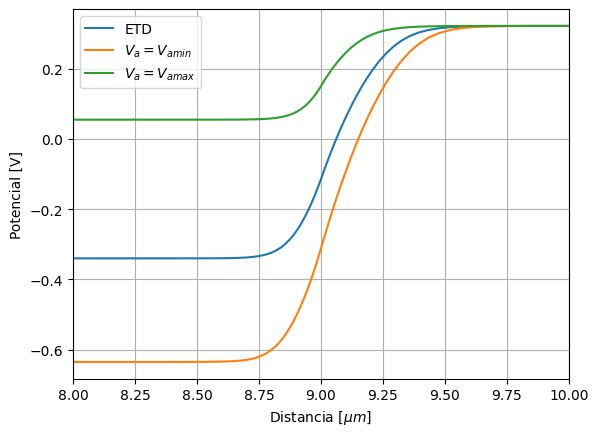

phi_bi = 0.6620211103275255


In [41]:
plt.figure()
plt.plot(1e4*x_Efield, phi_etd,label = "ETD")
plt.plot(1e4*x_Efield, phi_Vamin, label =r"$V_a = V_{amin}$")
plt.plot(1e4*x_Efield, phi_Vamax, label =r"$V_a = V_{amax}$")
plt.grid()
plt.legend()
plt.xlim([8,10])
plt.ylabel("Potencial [V]")
plt.xlabel(r"Distancia [$\mu m$]")
plt.savefig("res/fig_4_potencial.pdf")
plt.show()

phi_bi = phi_etd[-1] - phi_etd[0]

print(f"phi_bi = {phi_bi}")


# PUNTO 5

Utilizando la informaci ́on generada por DEVSIM (densidad de portado-
res y campo el ́ectrico), graficar las corrientes de arrastre y difusi ́on de electrones y huecos a lo

largo de todo el diodo. Grafique las dos corrientes de electrones en una figura y las de huecos en
otra. En cada figure grafique tambi ́en la suma de la componente de arrastre con la componente
difusi ́on. Son en total dos figuras con tres curvas cada una.

# PREGUNTAR, POR QUE LA SUMA NO ES CERO Y TIENE UNA PANZITA

In [18]:
q = 1.602e-19
D_p = 12.4 #Cm²/s
mu_p = 480 #Cm²/Vs

In [19]:
dp_dx_etd = np.diff(p_etd) / np.diff(x_Efield)
x_mid_etd = (x_Efield[1:] + x_Efield[:-1]) / 2
p_mid_etd = (p_etd[1:] + p_etd[:-1]) / 2
E_mid_etd = (E_etd[1:] + E_etd[:-1]) / 2

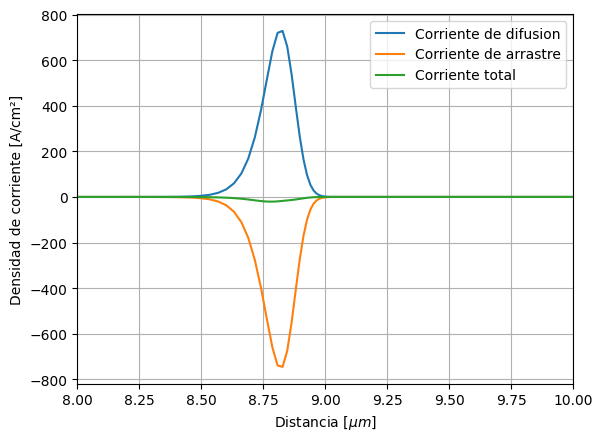

In [20]:
Jp_diff_etd = - q * D_p * dp_dx_etd
Jp_arr_etd = q * mu_p * E_mid_etd * p_mid_etd
plt.figure()
plt.plot(1e4*x_mid_etd,Jp_diff_etd, label= 'Corriente de difusion')
plt.plot(1e4*x_mid_etd,Jp_arr_etd, label= 'Corriente de arrastre')
plt.plot(1e4*x_mid_etd,Jp_diff_etd + Jp_arr_etd[:126], label= 'Corriente total')
plt.ylabel('Densidad de corriente [A/cm²]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()
plt.legend()
plt.xlim([8,10])
plt.savefig("res/fig_5_jp.pdf")
plt.show()

In [21]:
q = 1.602e-19
D_n = 35 #Cm²/s
mu_n = 1350 #Cm²/Vs

In [22]:
dn_dx_etd = np.diff(n_etd) / np.diff(x_Efield)
x_mid_etd = (x_Efield[1:] + x_Efield[:-1]) / 2
n_mid_etd = (n_etd[1:] + n_etd[:-1]) / 2
E_mid_etd = (E_etd[1:] + E_etd[:-1]) / 2



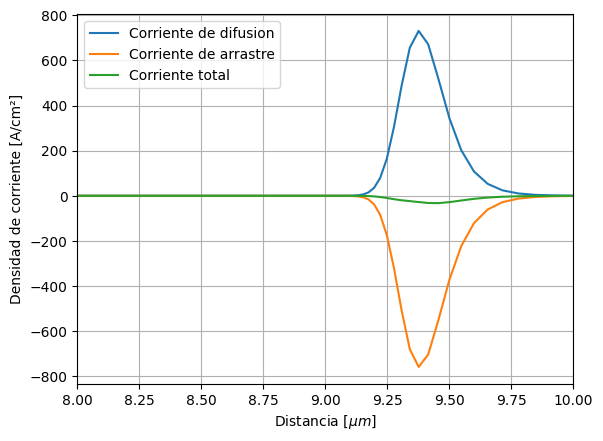

In [23]:
Jn_diff_etd = q * D_n * dn_dx_etd
Jn_arr_etd = q * mu_n * E_mid_etd * n_mid_etd
plt.figure()
plt.plot(1e4*x_mid_etd,Jn_diff_etd, label= 'Corriente de difusion')
plt.plot(1e4*x_mid_etd,Jn_arr_etd, label= 'Corriente de arrastre')
plt.plot(1e4*x_mid_etd,Jn_diff_etd + Jn_arr_etd, label= 'Corriente total')
plt.ylabel('Densidad de corriente [A/cm²]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()
plt.xlim([8,10])
plt.legend(

)
plt.savefig("res/fig_5_jn.pdf")
plt.show()

# PUNTO 6

DEVSIM Graficar la densidad de corriente con el modelo del diodo ideal de esta consigna.
Superponer con la curva de corriente generada por DEVSIM barriendo entre las dos tensiones
indicadas en la consigna. Utilizar una figura.
¿Cu ́anto difieren las curvas entre s ́ı? ¿Es la diferencia despreciable? Cuantificar y justificar.

In [24]:
ni  = 1e10      # Concentración intrínseca [cm^-3 o m^-3]

xp = 0.2196e-4       # Extensión de la zona de agotamiento hacia p
xn = 0.4392e-4       # Extensión de la zona de agotamiento hacia n

Vth = 25.9e-3     # Tensión térmica [V]

In [25]:
Js = q * ni**2 * (
    D_n / ((Wp - xp) * Na)
    + D_p / ((Wn - xn) * Nd)
)

In [26]:
Va = np.linspace(Va_min, Va_max, 1000)

J_ideal = Js * (np.exp(np.array(appliedVoltage)/ Vth) - 1)


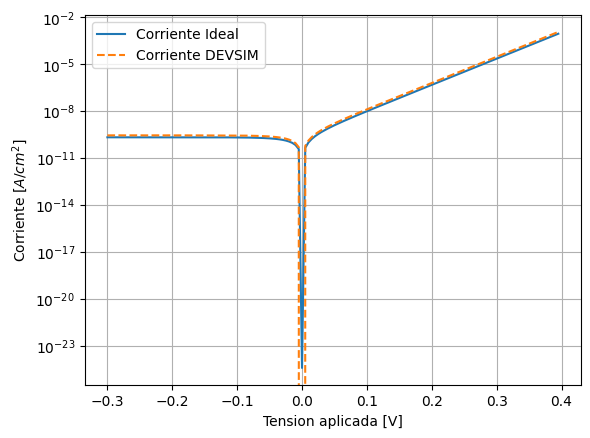

In [60]:
plt.figure()
plt.plot(appliedVoltage,np.abs(J_ideal), label = 'Corriente Ideal')
plt.plot(appliedVoltage,np.abs(np.array(totalCurrent)/np.array(altura)), label = 'Corriente DEVSIM', linestyle='dashed')
plt.semilogy()
plt.legend()
plt.ylabel(r'Corriente [$A/cm^2$]')
plt.xlabel(r"Tension aplicada [V]")
plt.grid()
plt.savefig("res/fig_6_corriente.pdf")
plt.show()

In [64]:
J_simulada = np.array(totalCurrent)/np.array(altura)

import numpy as np

# -----------------------------
# RMSE convencional
# -----------------------------
rmse = np.sqrt(np.mean((J_ideal - J_simulada)**2))

# -----------------------------
# Región positiva
# -----------------------------
mask_pos = (J_ideal > 0) & (J_simulada > 0)

rmse_log_pos = np.sqrt(
    np.mean(
        (
            np.log10(J_ideal[mask_pos])
            - np.log10(J_simulada[mask_pos])
        )**2
    )
)

# Factor multiplicativo equivalente
factor_pos = 10**rmse_log_pos

# -----------------------------
# Región negativa
# -----------------------------
mask_neg = (J_ideal < 0) & (J_simulada < 0)

rmse_log_neg = np.sqrt(
    np.mean(
        (
            np.log10(np.abs(J_ideal[mask_neg]))
            - np.log10(np.abs(J_simulada[mask_neg]))
        )**2
    )
)

# Factor multiplicativo equivalente
factor_neg = 10**rmse_log_neg

# -----------------------------
# Resultados
# -----------------------------
print("=== Error cuadrático medio ===")
print(f"RMSE = {rmse:.6e}")

print("\n=== Región positiva ===")
print(f"RMSE_log = {rmse_log_pos:.6e}")
print(f"Factor equivalente = {factor_pos:.3f}")

print("\n=== Región negativa ===")
print(f"RMSE_log = {rmse_log_neg:.6e}")
print(f"Factor equivalente = {factor_neg:.3f}")

=== Error cuadrático medio ===
RMSE = 3.974878e-05

=== Región positiva ===
RMSE_log = 1.179817e-01
Factor equivalente = 1.312

=== Región negativa ===
RMSE_log = 1.222092e-01
Factor equivalente = 1.325


# PUNTO 7 PREGUNTAR POR LOS VALORES DE XN Y XP (USAMOS ETD EN AMBAS O VMAX EN AMBAS O UNA Y UNA?) TAMBIEN PREGUNTAR POR LAS DIFERENCIAS CON LOS VALORES REALES

DEVSIM. Solo para la tensi ́on en directa. Medir el exceso de portadores minoritarios en
los bordes de la zona de carga espacial (SCR).
¿Se verifica la hip ́otesis de bajo nivel de inyecci ́on?
Calcular el exceso de minoritarios que esperar ́ıa obtener en cada borde de la SCR utilizando
las expresiones te ́oricas. Comparar el resultado con el provisto por DEVSIM.


In [68]:
print("xp_etd  :", x_Efield[idx_xp_etd])
print("xn_etd  :", x_Efield[idx_xn_etd])
print("xp_Vamax:", x_Efield[idx_xp_Vamax])
print("xn_Vamax:", x_Efield[idx_xn_Vamax])

xp_etd  : 0.0008647264898288679
xn_etd  : 0.0009626359450717764
xp_Vamax: 0.0008703063209540166
xn_Vamax: 0.0009477666764356945


In [69]:
n_xp_etd = n_etd[idx_xp_Vamax]
p_xn_etd = p_etd[idx_xn_Vamax]
n_xp_Vamax = n_Vamax[idx_xp_Vamax]
p_xn_Vamax = p_Vamax[idx_xn_Vamax]

In [70]:
print(f"p_xp_etd   = {n_xp_etd:.6e}")
print(f"n_xn_etd   = {p_xn_etd:.6e}")
print(f"p_xp_Vamax = {n_xp_Vamax:.6e}")
print(f"n_xn_Vamax = {p_xn_Vamax:.6e}")

p_xp_etd   = 2.603516e+04
n_xn_etd   = 6.029238e+04
p_xp_Vamax = 9.948301e+10
n_xn_Vamax = 1.971280e+11


In [71]:
ex_n_xp = n_xp_Vamax - n_xp_etd
ex_p_xn = p_xn_Vamax - p_xn_etd

print(f"exceso de n minoritarios   = {ex_n_xp:.6e}")
print(f"exceso de p minoritarios   = {ex_p_xn:.6e}")

exceso de n minoritarios   = 9.948298e+10
exceso de p minoritarios   = 1.971279e+11


![image.png](res/img_2.png)
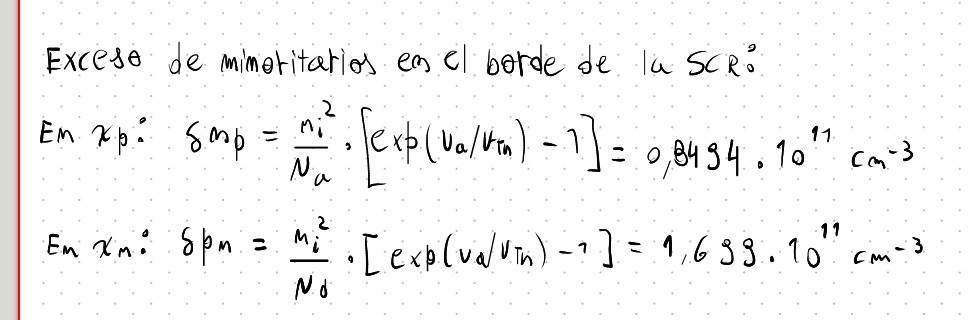

# PUNTO 8 Preguntar (TIENEN SENTIDO LOS GRAFICOS)

DEVSIM. Solo para la tensi ́on en directa. Calcular las corrientes de difusi ́on de mayori-
tarios en las QNR. Utilizar las densidades de portadores. Realizar un gr ́afico para la QNR-N y

otro para la QNR-P. Son en total dos figuras.
Analizar las magnitudes obtenidas en las figuras y justif ́ıquelas.
¿Es v ́alida la hip ́otesis de cuasi-neutrilidad?

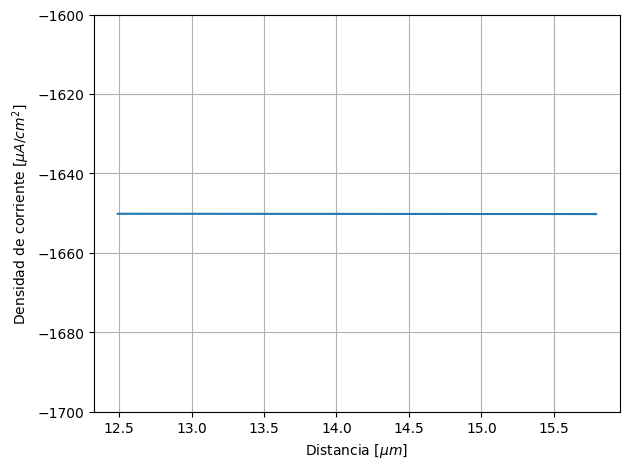

In [67]:
q = 1.602e-19
D_n = 35  #Cm²/s
mu_n = 1350  #Cm²/Vs


dn_dx_Vamax = np.diff(n_Vamax) / np.diff(x_Efield)
x_mid_Vamax = (x_Efield[1:] + x_Efield[:-1]) / 2

Jn_diff_Vamax = q * D_n * dn_dx_Vamax
plt.figure()
plt.plot(1e4 * x_mid_Vamax[idx_xn_Vamax+24:], 1e6*Jn_diff_Vamax[idx_xn_Vamax+24:], label='Corriente de difusion')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()
# 1. Obtén el eje actual
ax = plt.gca()

# 2. Configura el formateador (cambia 'yaxis' por 'xaxis' si es el eje horizontal)
formatter = ax.yaxis.get_major_formatter()

# 3. Desactiva el offset y activa el texto matemático
formatter.set_useOffset(False)

ax.yaxis.set_label_text(r'Densidad de corriente [$\mu A/cm^2$]')
plt.ticklabel_format(style='sci', useOffset=False, axis='both')

plt.ylim([-1700,-1600])
plt.tight_layout()
plt.savefig("res/fig_8_qnr_n.pdf")
plt.show()

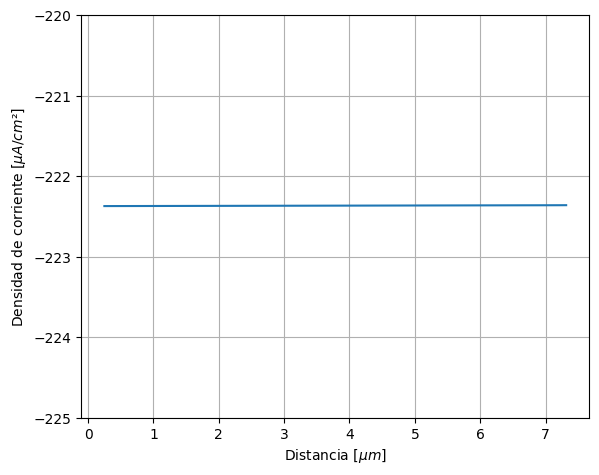

In [35]:
q = 1.602e-19
D_p = 12.4  #Cm²/s
mu_p = 480  #Cm²/Vs


dp_dx_Vamax = np.diff(p_Vamax) / np.diff(x_Efield)
x_mid_Vamax = (x_Efield[1:] + x_Efield[:-1]) / 2

Jp_diff_Vamax = -q * D_p * dp_dx_Vamax
plt.figure()
# 1. Obtén el eje actual
ax = plt.gca()

# 2. Configura el formateador (cambia 'yaxis' por 'xaxis' si es el eje horizontal)
formatter = ax.yaxis.get_major_formatter()

# 3. Desactiva el offset y activa el texto matemático
formatter.set_useOffset(False)
plt.ticklabel_format(style='sci', useOffset=False, axis='both')
plt.plot(1e4 * x_mid_Vamax[:idx_xp_Vamax-31], 1e3*Jp_diff_Vamax[:idx_xp_Vamax-31], label='Corriente de difusion')



plt.xlabel(r"Distancia [$\mu m$]")


plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')


plt.grid()

plt.tight_layout()
plt.ylim([-225,-220])
plt.savefig("res/fig_8_qnr_p.pdf")
plt.show()

# PUNTO 9 (PREGUNTAR)

DEVSIM. Solo para la tensi ́on en directa. Calcular las corrientes de arrastre de mino-
ritarios en las QNR. Utilizar el campo el ́ectrico y las densidades de portadores. Realizar un

gr ́afico para la QNR-N y otro para la QNR-P. Son en total dos figuras.

2

Dispositivos Semiconductores
1
er cuatrimestre de 2026
Analizar las magnitudes obtenidas en las figuras y justif ́ıquelas.
¿C ́omo se comparan las magnitudes obtenidas con las del resto de las corrientes de arrastre
y difusi ́on? ¿Por qu ́e? (se recomienda resolver primero el  ́ıtem siguiente antes de responder
esta pregunta).

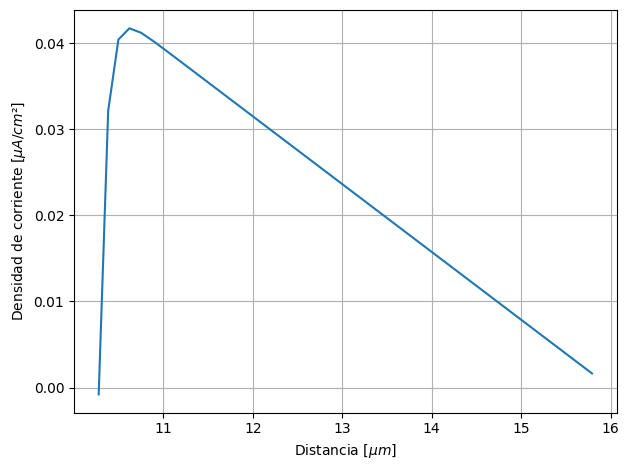

In [36]:
q = 1.602e-19
D_p = 12.4  #Cm²/s
mu_p = 480  #Cm²/Vs
x_mid_Vamax = (x_Efield[1:] + x_Efield[:-1]) / 2
p_mid_Vamax = (p_Vamax[1:] + p_Vamax[:-1]) / 2
E_mid_Vamax = (E_Vamax[1:] + E_Vamax[:-1]) / 2
Jp_arr_Vamax = q * mu_p * E_mid_Vamax * p_mid_Vamax
plt.figure()
plt.plot(1e4 * x_mid_Vamax[idx_xn_Vamax+16:], 1e6*Jp_arr_Vamax[idx_xn_Vamax+16:], label='Corriente de arrastre')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()

plt.tight_layout()
plt.savefig("res/fig_9_qnr_n.pdf")
plt.show()

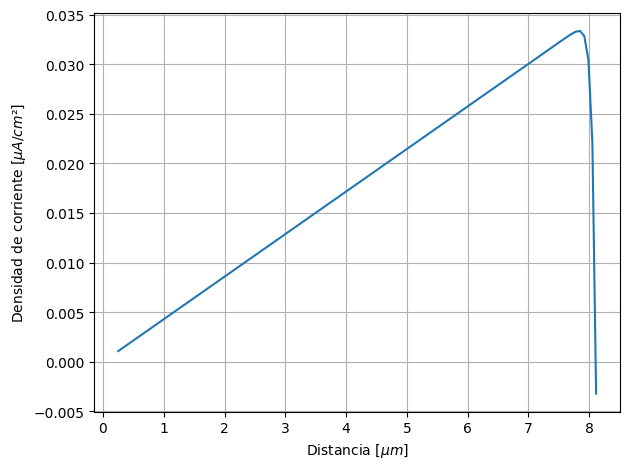

In [37]:
q = 1.602e-19
D_n = 35  #Cm²/s
mu_n = 1350  #Cm²/Vs
x_mid_Vamax = (x_Efield[1:] + x_Efield[:-1]) / 2
n_mid_Vamax = (n_Vamax[1:] + n_Vamax[:-1]) / 2
E_mid_Vamax = (E_Vamax[1:] + E_Vamax[:-1]) / 2
Jn_arr_Vamax = q * mu_n * E_mid_Vamax * n_mid_Vamax
plt.figure()
plt.plot(1e4 * x_mid_Vamax[:idx_xp_Vamax-21], 1e6*Jn_arr_Vamax[:idx_xp_Vamax-21], label='Corriente de arrastre')
plt.ylabel(r'Densidad de corriente [$\mu A/cm²$]')
plt.xlabel(r"Distancia [$\mu m$]")
plt.grid()

plt.tight_layout()
plt.savefig("res/fig_9_qnr_p.pdf")
plt.show()

#### Guardar resultados

In [38]:
folder_path = "data_sin_SRH"
os.makedirs(folder_path, exist_ok=True)

if enable_SRH == False:
    ## Barrido de tension
    np.save('data_sin_SRH/voltage.npy', appliedVoltage)
    np.save('data_sin_SRH/electron_current.npy', electronCurrent)
    np.save('data_sin_SRH/hole_current.npy', holeCurrent)
    np.save('data_sin_SRH/total_current.npy', totalCurrent)

    ## Valores en funcion de la posicion cuando Vd = 0V
    np.save('data_sin_SRH/n_etd.npy', n_etd)
    np.save('data_sin_SRH/p_etd.npy', p_etd)
    np.save('data_sin_SRH/Efield_etd.npy', E_etd)
    np.save('data_sin_SRH/phi_etd.npy', phi_etd)
    np.save('data_sin_SRH/Jn_etd.npy', Jn_etd)
    np.save('data_sin_SRH/Jp_etd.npy', Jp_etd)

    ## Valores en funcion de la posicion cuando Vd = Va_min
    np.save('data_sin_SRH/n_Va_min.npy', n_Vamin)
    np.save('data_sin_SRH/p_Va_min.npy', p_Vamin)
    np.save('data_sin_SRH/Efield_Va_min.npy', E_Vamin)
    np.save('data_sin_SRH/phi_Va_min.npy', phi_Vamin)
    np.save('data_sin_SRH/Jn_Va_min.npy', Jn_Vamin)
    np.save('data_sin_SRH/Jp_Va_min.npy', Jp_Vamin)

    ## Valores en funcion de la posicion cuando Vd = Va_max
    np.save('data_sin_SRH/n_Va_max.npy', n_Vamax)
    np.save('data_sin_SRH/p_Va_max.npy', p_Vamax)
    np.save('data_sin_SRH/Efield_Va_max.npy', E_Vamax)
    np.save('data_sin_SRH/phi_Va_max.npy', phi_Vamax)
    np.save('data_sin_SRH/Jn_Va_max.npy', Jn_Vamax)
    np.save('data_sin_SRH/Jp_Va_max.npy', Jp_Vamax)

    ## Guardar vector de coordenadas en X
    x = 1e4*np.array(get_node_model_values(device=device, region=region, name="x"))
    np.save('data_sin_SRH/x_vector.npy', x)
    np.save('data_sin_SRH/x_vector_Efield.npy', x_Efield)
else:
    ## Barrido de tension
    np.save('data_sin_SRH/electron_current_srh.npy', electronCurrent)
    np.save('data_sin_SRH/hole_current_srh.npy', holeCurrent)
    np.save('data_sin_SRH/total_current_srh.npy', totalCurrent)